# 02 — Preprocessing: mesh → 128×128 grid

**Cíl:** Převést všech 800 nestrukturovaných simulací na pravidelné mřížky 128×128,
sestavit vstupní a výstupní kanály, znormalizovat a uložit jako jeden `.npz` soubor
připravený k tréninku.

**Proč:** U-Net (konvoluční síť) potřebuje strukturovaný vstup jako obrázek,
ne mrak rozházených bodů. Tady ta data "porastrujeme".

**Výstup:** `../data/processed.npz` obsahující:
- `X` — vstupy, tvar `(800, 3, 128, 128)`: SDF, úhel náběhu, rychlost
- `Y` — výstupy, tvar `(800, 3, 128, 128)`: tlak, u, v
- normalizační statistiky pro denormalizaci při inferenci

---

## 1. Importy a konfigurace

In [1]:
import os
import time
import numpy as np
import airfrans as af
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# --- Konfigurace ---
DATA_ROOT = "../data"
DATASET_DIR = os.path.join(DATA_ROOT, "Dataset")
OUTPUT_PATH = os.path.join(DATA_ROOT, "processed.npz")

GRID_SIZE = 128                      # rozliseni mrizky (128x128)
DOMAIN = (-1.0, 3.0, -1.5, 1.5)      # (x_min, x_max, y_min, y_max) v metrech

print(f"Grid: {GRID_SIZE}x{GRID_SIZE}")
print(f"Domena: x in [{DOMAIN[0]}, {DOMAIN[1]}], y in [{DOMAIN[2]}, {DOMAIN[3]}]")
print(f"Vystup: {OUTPUT_PATH}")

Grid: 128x128
Domena: x in [-1.0, 3.0], y in [-1.5, 1.5]
Vystup: ../data\processed.npz


## 2. Načtení dat

Načteme tréninkovou část (800 simulací). Pokud jsi to dělal v notebooku 01,
data už jsou stažená.

In [2]:
dataset_list, names = af.dataset.load(
    root=DATASET_DIR,
    task="full",
    train=True,
)
print(f"Nacteno {len(dataset_list)} simulaci")
print(f"Tvar prvni: {dataset_list[0].shape}")

Loading dataset (task: full, split: train): 100%|██████████| 800/800 [04:43<00:00,  2.83it/s]

Nacteno 800 simulaci
Tvar prvni: (181794, 12)


## 3. Funkce pro převod jedné simulace na grid

Tady je jádro preprocessingu. Připomínka struktury sloupců (zjištěno v notebooku 01):

| Sloupec | Význam |
|---------|--------|
| 0, 1 | x, y souřadnice |
| 2, 3 | inlet velocity x, y (konstanta) |
| 4 | SDF (vzdálenost od airfoilu) |
| 5, 6 | normála x, y |
| 7, 8 | rychlost u, v |
| 9 | tlak |
| 10 | turbulentní viskozita |
| 11 | flag povrchu |

`griddata` interpoluje hodnoty z rozházených bodů na pravidelnou mřížku. Používáme
`method='linear'` (lineární interpolace) — kompromis mezi kvalitou a rychlostí.

In [6]:
# Pripravime pravidelnou mrizku jednou (je stejna pro vsechny simulace)
x_min, x_max, y_min, y_max = DOMAIN
grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, GRID_SIZE),
    np.linspace(y_min, y_max, GRID_SIZE),
)
grid_points = (grid_x, grid_y)


def simulation_to_grid(sim):
    """Prevede jednu simulaci (mrak bodu) na grid 128x128.

    Vraci:
        inputs:  (3, 128, 128) - [SDF, uhel_nabehu, rychlost]
        outputs: (3, 128, 128) - [tlak, u, v]
    """
    positions = sim[:, 0:2]      # x, y souradnice bodu
    inlet_vx  = sim[0, 2]        # vstupni rychlost x (konstanta)
    inlet_vy  = sim[0, 3]        # vstupni rychlost y (konstanta)
    sdf       = sim[:, 4]        # signed distance function
    u         = sim[:, 7]        # rychlost u
    v         = sim[:, 8]        # rychlost v
    pressure  = sim[:, 9]        # tlak

    # Interpolace kazdeho pole na grid
    def interp(values):
        return griddata(positions, values, grid_points, method="linear", fill_value=0.0)

    sdf_grid = interp(sdf)
    p_grid   = interp(pressure)
    u_grid   = interp(u)
    v_grid   = interp(v)

    # Odvozene skalarni vel?iciny vstupu
    speed = np.sqrt(inlet_vx**2 + inlet_vy**2)
    angle = np.arctan2(inlet_vy, inlet_vx)   # uhel nabehu v radianech

    # Vstupni kanaly: SDF (geometrie) + uhel + rychlost (broadcast jako konstanty)
    inputs = np.stack([
        sdf_grid,
        np.full((GRID_SIZE, GRID_SIZE), angle),
        np.full((GRID_SIZE, GRID_SIZE), speed),
    ], axis=0).astype(np.float32)

    # Vystupni kanaly
    outputs = np.stack([p_grid, u_grid, v_grid], axis=0).astype(np.float32)

    return inputs, outputs

## 4. Test na jedné simulaci

Než pustíme všech 800, ověříme že funkce funguje a vizualizujeme výsledek.
**Toto je kontrolní bod** — pokud grid vypadá rozumně, můžeme dál.

Vstup:  (3, 128, 128)
Vystup: (3, 128, 128)


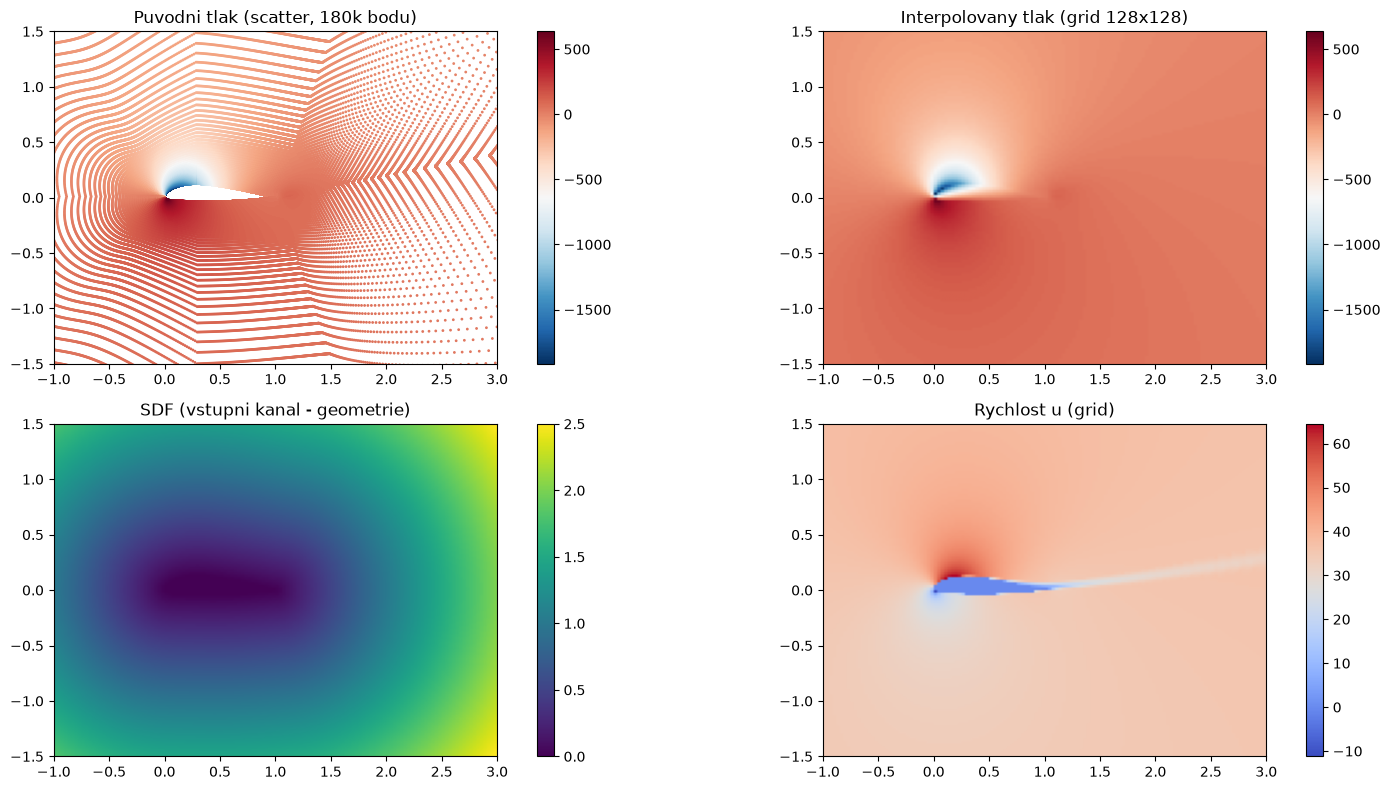

In [7]:
# Test na prvni simulaci
test_in, test_out = simulation_to_grid(dataset_list[0])
print(f"Vstup:  {test_in.shape}")
print(f"Vystup: {test_out.shape}")

# Vizualizace: porovnani puvodni scatter vs interpolovany grid
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

sim = dataset_list[0]

# Puvodni tlak (scatter)
ax = axes[0, 0]
vmin, vmax = np.percentile(sim[:, 9], [1, 99])
sc = ax.scatter(sim[:,0], sim[:,1], c=sim[:,9], cmap="RdBu_r", s=1, vmin=vmin, vmax=vmax)
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max); ax.set_aspect("equal")
ax.set_title("Puvodni tlak (scatter, 180k bodu)")
plt.colorbar(sc, ax=ax)

# Interpolovany tlak (grid)
ax = axes[0, 1]
im = ax.imshow(test_out[0], cmap="RdBu_r", origin="lower",
               extent=DOMAIN, vmin=vmin, vmax=vmax, aspect="equal")
ax.set_title("Interpolovany tlak (grid 128x128)")
plt.colorbar(im, ax=ax)

# SDF grid
ax = axes[1, 0]
im = ax.imshow(test_in[0], cmap="viridis", origin="lower", extent=DOMAIN, aspect="equal")
ax.set_title("SDF (vstupni kanal - geometrie)")
plt.colorbar(im, ax=ax)

# Rychlost u grid
ax = axes[1, 1]
im = ax.imshow(test_out[1], cmap="coolwarm", origin="lower", extent=DOMAIN, aspect="equal")
ax.set_title("Rychlost u (grid)")
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

**Co bys měl vidět:**
- **Vlevo nahoře** (scatter) vs **vpravo nahoře** (grid) — měly by vypadat podobně,
  ale grid je hladší a pravidelný. Podtlaková modrá zóna nad křídlem musí být v obou.
- **SDF** — gradient vzdálenosti, tmavá u křídla, světlá daleko.
- **Rychlost u** — vyšší hodnoty nad křídlem.

Pokud grid vypadá jako šum nebo úplně jinak než scatter, něco je špatně — napiš.

## 5. Zpracování všech simulací

Teď pustíme `simulation_to_grid` na všech 800. **Tohle potrvá pár minut**
(interpolace je výpočetně náročná). Sleduj progress bar.

⚠️ Spustí se jednou, výsledek se uloží. Příště už jen načteš `processed.npz`.

In [8]:
from tqdm.notebook import tqdm

N = len(dataset_list)
X = np.zeros((N, 3, GRID_SIZE, GRID_SIZE), dtype=np.float32)
Y = np.zeros((N, 3, GRID_SIZE, GRID_SIZE), dtype=np.float32)

start = time.time()
for i in tqdm(range(N), desc="Interpolace"):
    inp, out = simulation_to_grid(dataset_list[i])
    X[i] = inp
    Y[i] = out

elapsed = time.time() - start
print(f"\nHotovo za {elapsed:.1f}s ({elapsed/N*1000:.0f} ms/simulace)")
print(f"X: {X.shape}, {X.nbytes/1e6:.0f} MB")
print(f"Y: {Y.shape}, {Y.nbytes/1e6:.0f} MB")

Interpolace:   0%|          | 0/800 [00:00<?, ?it/s]


Hotovo za 15317.4s (19147 ms/simulace)
X: (800, 3, 128, 128), 157 MB
Y: (800, 3, 128, 128), 157 MB


## 6. Kontrola NaN a rozsahů

Interpolace občas vyrobí NaN (pokud bod meshe je mimo doménu). Zkontrolujeme
a případně ošetříme.

In [9]:
# Kontrola NaN
n_nan_X = np.isnan(X).sum()
n_nan_Y = np.isnan(Y).sum()
print(f"NaN ve vstupech: {n_nan_X}")
print(f"NaN ve vystupech: {n_nan_Y}")

# Pokud jsou NaN, nahradime nulou
if n_nan_X > 0:
    X = np.nan_to_num(X, nan=0.0)
    print("  -> NaN ve vstupech nahrazeny nulou")
if n_nan_Y > 0:
    Y = np.nan_to_num(Y, nan=0.0)
    print("  -> NaN ve vystupech nahrazeny nulou")

# Rozsahy jednotlivych kanalu
print("\nRozsahy vstupnich kanalu:")
for i, name in enumerate(["SDF", "uhel", "rychlost"]):
    print(f"  {name:10s}: [{X[:,i].min():8.3f}, {X[:,i].max():8.3f}]  mean={X[:,i].mean():7.3f}")
print("Rozsahy vystupnich kanalu:")
for i, name in enumerate(["tlak", "u", "v"]):
    print(f"  {name:10s}: [{Y[:,i].min():8.1f}, {Y[:,i].max():8.1f}]  mean={Y[:,i].mean():7.2f}")

NaN ve vstupech: 0
NaN ve vystupech: 0

Rozsahy vstupnich kanalu:
  SDF       : [   0.000,    2.501]  mean=  1.098
  uhel      : [  -0.086,    0.261]  mean=  0.079
  rychlost  : [  31.283,   93.592]  mean= 62.116
Rozsahy vystupnich kanalu:
  tlak      : [-34555.8,   4216.4]  mean= -24.03
  u         : [   -87.9,    223.6]  mean=  61.26
  v         : [   -96.7,    157.7]  mean=   4.33


## 7. Normalizace

Neuronka konverguje líp když mají vstupy i výstupy podobné měřítko (zero mean,
unit variance). Spočítáme průměr a std **per kanál** a přeškálujeme.

**Důležité:** statistiky výstupů (`Y_mean`, `Y_std`) si uložíme, protože při inferenci
budeme muset predikce **denormalizovat** zpátky do fyzikálních jednotek (Pa, m/s).

In [10]:
# Normalizace per kanal. Statistiky pocitame pres vsechny vzorky a pixely (osy 0,2,3)
def compute_stats(arr):
    mean = arr.mean(axis=(0, 2, 3), keepdims=True)
    std  = arr.std(axis=(0, 2, 3), keepdims=True)
    return mean, std

X_mean, X_std = compute_stats(X)
Y_mean, Y_std = compute_stats(Y)

# Pridame male epsilon aby nedoslo k deleni nulou
eps = 1e-8
X_norm = (X - X_mean) / (X_std + eps)
Y_norm = (Y - Y_mean) / (Y_std + eps)

print("Po normalizaci (melo by byt ~0 mean, ~1 std):")
print(f"  X: mean={X_norm.mean():.4f}, std={X_norm.std():.4f}")
print(f"  Y: mean={Y_norm.mean():.4f}, std={Y_norm.std():.4f}")

print("\nUlozene statistiky vystupu (pro denormalizaci pri inferenci):")
for i, name in enumerate(["tlak", "u", "v"]):
    print(f"  {name:6s}: mean={Y_mean[0,i,0,0]:9.2f}, std={Y_std[0,i,0,0]:9.2f}")

Po normalizaci (melo by byt ~0 mean, ~1 std):
  X: mean=-0.0000, std=1.0000
  Y: mean=-0.0000, std=1.0000

Ulozene statistiky vystupu (pro denormalizaci pri inferenci):
  tlak  : mean=   -24.03, std=   339.27
  u     : mean=    61.26, std=    18.92
  v     : mean=     4.33, std=     6.78


## 8. Uložení

Vše uložíme do jednoho `.npz` souboru. Obsahuje normalizovaná data + statistiky.

In [11]:
np.savez_compressed(
    OUTPUT_PATH,
    X=X_norm,
    Y=Y_norm,
    X_mean=X_mean, X_std=X_std,
    Y_mean=Y_mean, Y_std=Y_std,
    names=np.array(names),
)

size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
print(f"Ulozeno: {OUTPUT_PATH}")
print(f"Velikost: {size_mb:.0f} MB")
print(f"\nObsah:")
print(f"  X (vstupy):  {X_norm.shape}")
print(f"  Y (vystupy): {Y_norm.shape}")
print(f"  + normalizacni statistiky")

Ulozeno: ../data\processed.npz
Velikost: 185 MB

Obsah:
  X (vstupy):  (800, 3, 128, 128)
  Y (vystupy): (800, 3, 128, 128)
  + normalizacni statistiky


## 9. Ověření že se to dá načíst zpátky

Rychlý sanity check — načteme uložený soubor a ověříme že data sedí.

Klice v souboru: ['X', 'Y', 'X_mean', 'X_std', 'Y_mean', 'Y_std', 'names']
X: (800, 3, 128, 128), dtype=float32
Y: (800, 3, 128, 128), dtype=float32


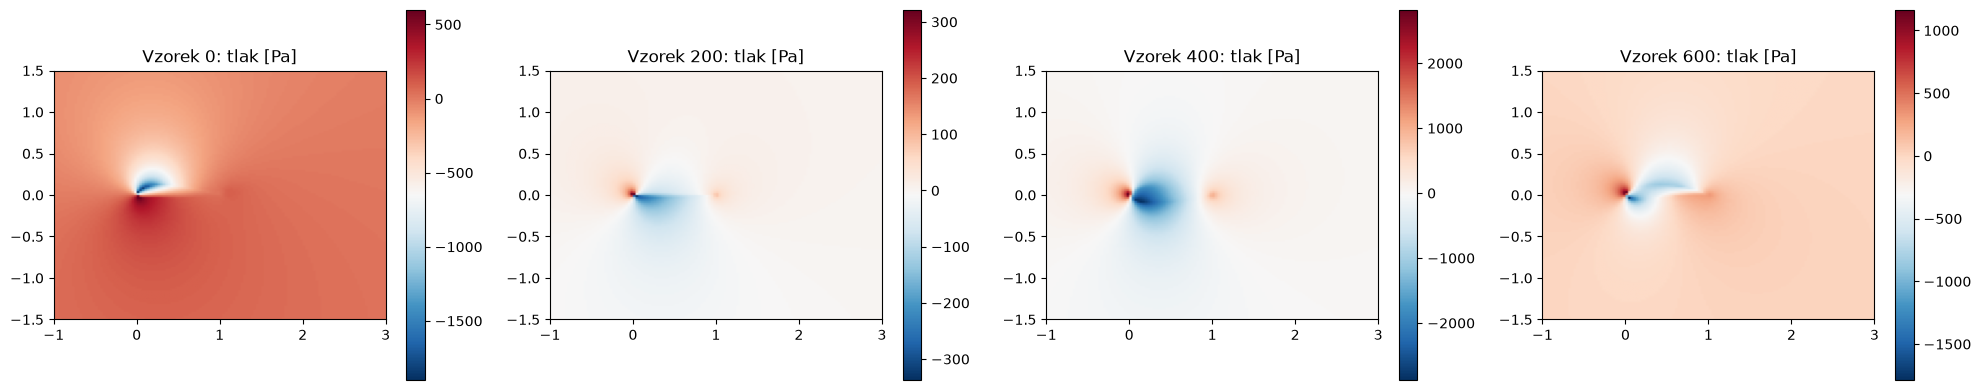


Preprocessing hotovy! Data jsou pripravena k treninku.


In [12]:
# Nacteni zpatky
data = np.load(OUTPUT_PATH)
print("Klice v souboru:", list(data.keys()))
print(f"X: {data['X'].shape}, dtype={data['X'].dtype}")
print(f"Y: {data['Y'].shape}, dtype={data['Y'].dtype}")

# Vizualizace nekolika nahodnych vzorku (denormalizovany tlak)
idx_samples = [0, 200, 400, 600]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, idx in zip(axes, idx_samples):
    # Denormalizace tlaku zpatky do Pa
    p_norm = data["Y"][idx, 0]
    p_pa = p_norm * data["Y_std"][0,0,0,0] + data["Y_mean"][0,0,0,0]
    im = ax.imshow(p_pa, cmap="RdBu_r", origin="lower", extent=DOMAIN, aspect="equal")
    ax.set_title(f"Vzorek {idx}: tlak [Pa]")
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\nPreprocessing hotovy! Data jsou pripravena k treninku.")

## Hotovo!

Máš `processed.npz` — 800 simulací jako pravidelné mřížky, normalizované,
připravené k tréninku.

**Co dál (notebook 03):**
- PyTorch `Dataset` + `DataLoader` (načte `processed.npz`, rozdělí train/val)
- U-Net model (`segmentation-models-pytorch`)
- Tréninkový loop
- Sledování loss

Napiš Claudovi **"hotovo, jdeme trenovat"** a pustíme se do toho!

---

**Tip:** Až tohle doběhne, commitni milestone:
```
git add notebooks/02_preprocess_to_grid.ipynb
git commit -m "Add notebook 02: mesh to grid preprocessing"
git push
```
(Pozn.: `processed.npz` se do gitu nenahraje — je v `.gitignore`. To je správně,
je to odvozený soubor který si každý vyrobí spuštěním notebooku.)